In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler


In [2]:
class NeuralNet:
    def __init__(self,x,y,lr,epoch):
        np.random.seed(322)
        self.input      = x
        self.weights1   = np.random.rand(self.input.shape[1],6) 
        self.weights2   = np.random.rand(6,1)                 
        self.y          = y
        self.output     = np.zeros(self.y.shape)
        self.lr         = lr
        self.epoch      = epoch
        self.costlist   = []
        
    @staticmethod    
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))
    
    @staticmethod    
    def _sigmoid_derivative(x): return x * (1 - x)      
    
    @staticmethod
    def cost(y_target,y_output):
        return 0.5*np.sum(np.square(np.subtract(y_target,y_output)))
    
    def feedforward(self):
        self.layer1 = self._sigmoid(np.dot(self.input, self.weights1))
        self.output = self._sigmoid(np.dot(self.layer1, self.weights2))

    def backprop(self):
        # application of the chain rule to find derivative of the cost function with respect to weights2 and weights1
        d_weights2 = np.dot(self.layer1.T, ((self.y - self.output) * self._sigmoid_derivative(self.output)))
        d_weights1 = np.dot(self.input.T,  (np.dot((self.y - self.output) * self._sigmoid_derivative(self.output), self.weights2.T) * self._sigmoid_derivative(self.layer1)))

        # update the weights 
        self.weights1 += d_weights1 * self.lr
        self.weights2 += d_weights2 * self.lr     
        
    def train(self):
        for i in range (self.epoch):
            self.feedforward()
            self.backprop()
            self.costlist.append(self.cost(self.y,self.output))
            
    def predict(self,input_data):
        self.input=input_data
        self.feedforward()
        return self.output

    sepal_length  sepal_width  petal_length  petal_width          species
0            5.1          3.5           1.4          0.2      Iris-setosa
1            4.9          3.0           1.4          0.2      Iris-setosa
2            4.7          3.2           1.3          0.2      Iris-setosa
3            4.6          3.1           1.5          0.2      Iris-setosa
4            5.0          3.6           1.4          0.2      Iris-setosa
..           ...          ...           ...          ...              ...
75           6.0          3.4           4.5          1.6  Iris-versicolor
76           6.7          3.1           4.7          1.5  Iris-versicolor
77           6.3          2.3           4.4          1.3  Iris-versicolor
78           5.6          3.0           4.1          1.3  Iris-versicolor
79           5.5          2.5           4.0          1.3  Iris-versicolor

[80 rows x 5 columns]
Total Instances on each iris species class
Iris-setosa        40
Iris-versicolor    40
Na

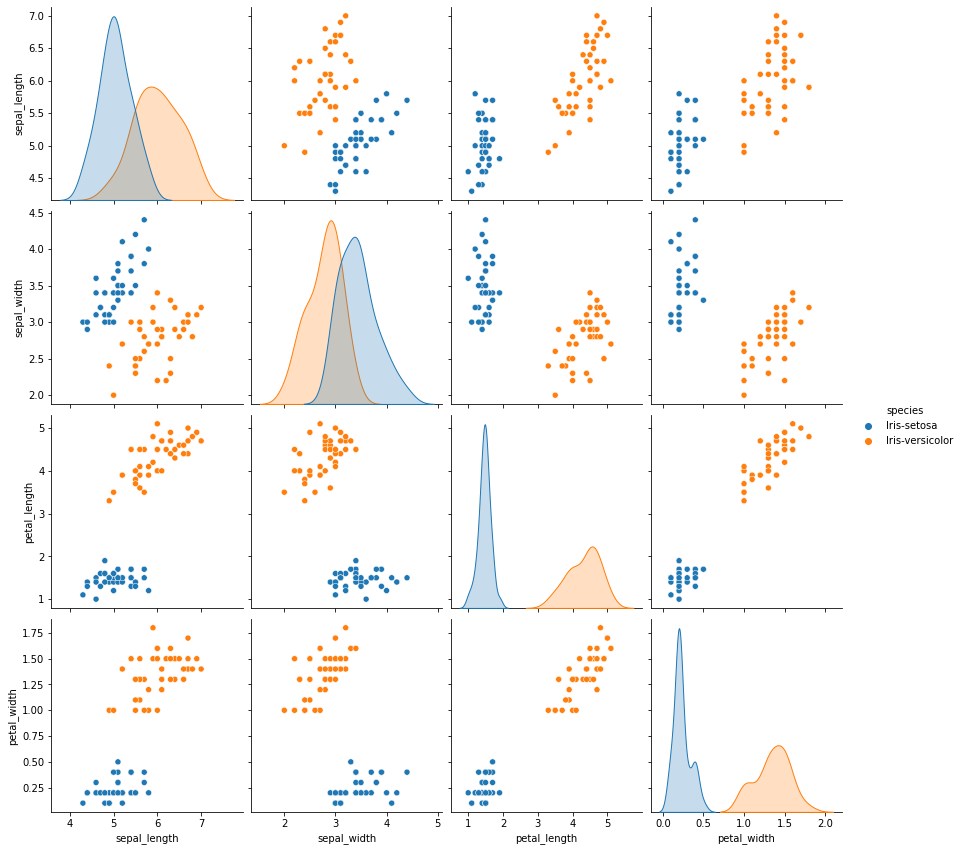

Input values before and after Scaling


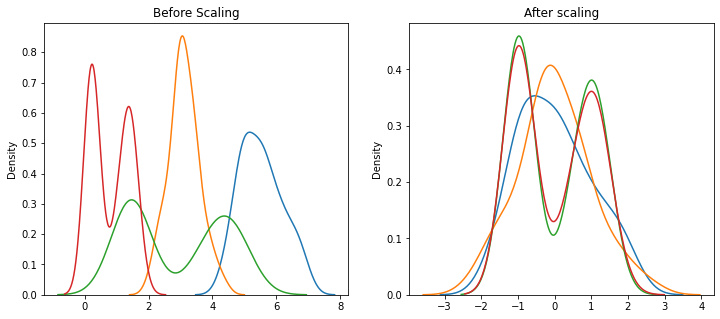

In [3]:




##Training data
data=pd.read_csv("IRIS_TrainData.csv",header=0)
print(data)
print("Total Instances on each iris species class")
print (data["species"].value_counts())
sns.pairplot(data, hue="species", height=3, diag_kind="kde")
plt.show(sns)


x_train=[]
y_train=[]
for i in range(0,len(data)):
    x_train.append([data.values[i,0],data.values[i,1],data.values[i,2],data.values[i,3]])
    if data.values[i,4]=='Iris-setosa':
        y_train.append([0])
    else:
        y_train.append([1])


#####################################################################
#Normalising the inputs
sc = StandardScaler()
sc.fit(x_train)
xtrain=sc.transform(x_train)

#Plot to visualise the input values before and after scaling
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title('Before Scaling')
ax2.set_title('After scaling')
print("Input values before and after Scaling")
label_names=['sepal_length','sepal_width','petal_length','petal_width']
for i in range(0,4):
    t1=[]
    t2=[]
    for row1 in x_train:
        t1.append(row1[i])
    for row2 in xtrain:
        t2.append(row2[i])
    sns.kdeplot(t1,ax=ax1,label=label_names[i])
    sns.kdeplot(t2,ax=ax2,label=label_names[i])
plt.show()

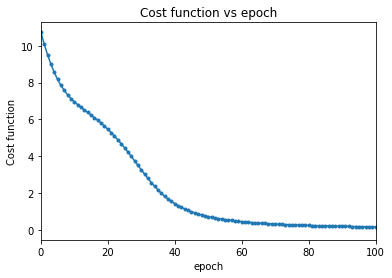


sepal_length  sepal_width  petal_length  petal_width  Neuralnet_output  Species
        4.4          3.2           1.3          0.2      [0.00886593]   Iris-setosa
        5.0          3.5           1.6          0.6      [0.01604603]   Iris-setosa
        5.6          2.7           4.2          1.3      [0.9930931]   Iris-versicolor
        5.7          3.0           4.2          1.2      [0.98787638]   Iris-versicolor


In [4]:
nn = NeuralNet(x=xtrain,y=np.array(y_train),lr=0.03,epoch=2000)
nn.train()


##Plotting the cost vs epoch
ep=[]
for i in range (0,len(nn.costlist)):
    ep.append(i)
plt.plot(ep,nn.costlist,marker = '.')
plt.xlabel('epoch')
plt.ylabel('Cost function')
plt.title("Cost function vs epoch")
plt.xlim((0,100))
plt.show()

###########################################################################
##Normalising the inputs of test data

x_test=[[4.4,3.2,1.3,0.2],[5.0,3.5,1.6,0.6],[5.6,2.7,4.2,1.3],[5.7,3.0,4.2,1.2]]
xtest=sc.transform(x_test)
out=nn.predict(xtest)

###########################################################################
##Labeling the test data based on the output of the Neuralnet
species=[]
print("\nsepal_length  sepal_width  petal_length  petal_width  Neuralnet_output  Species")
for i in range(0,len(xtest)):
    if(out[i]<0.5):
        species.append('Iris-setosa')
    else:
        species.append('Iris-versicolor')
    print("       ",x_test[i][0],"        ",x_test[i][1],"         ",x_test[i][2],"        ",x_test[i][3],"    ",out[i]," ",species[i])


#############################################################        


In [16]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(solver='adam', alpha=0.1, hidden_layer_sizes=(6, 1))

clf.fit(xtrain,np.array(y_train))
out=clf.predict(x_test)

species=[]
print("\nsepal_length  sepal_width  petal_length  petal_width  Neuralnet_output  Species")
for i in range(0,len(xtest)):
    if(out[i]<0.5):
        species.append('Iris-setosa')
    else:
        species.append('Iris-versicolor')
    print("       ",x_test[i][0],"        ",x_test[i][1],"         ",x_test[i][2],"        ",x_test[i][3],"    ",out[i]," ",species[i])



sepal_length  sepal_width  petal_length  petal_width  Neuralnet_output  Species
        4.4          3.2           1.3          0.2      0   Iris-setosa
        5.0          3.5           1.6          0.6      0   Iris-setosa
        5.6          2.7           4.2          1.3      1   Iris-versicolor
        5.7          3.0           4.2          1.2      1   Iris-versicolor


C:\Users\servo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)
C:\Users\servo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
